<a href="https://colab.research.google.com/github/bean-42026/Brandon-Data-Analytics-LaGuardia-2026/blob/main/Brandon_Python_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df = df[['encounter_id', 'age']]

In [ ]:
def combine_age_groups(age_range):
    if age_range in ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)']:
        return 'non-Medicare age'
    elif age_range in ['[60-70)', '[70-80)', '[80-90)', '[90-100)']:
        return 'Medicare age'
    else:
        return 'Unknown'

In [ ]:
df['combined_age_group'] = df['age'].apply(combine_age_groups)

In [ ]:
combined_df = df[['encounter_id', 'combined_age_group']].dropna()

In [ ]:
combined_df.head()

,encounter_id,combined_age_group
0,2278392,non-Medicare age
1,149190,non-Medicare age
2,64410,non-Medicare age
3,500364,non-Medicare age
4,16680,non-Medicare age


In [ ]:
desc_stats = combined_df.groupby('combined_age_group')["encounter_id"].agg(['count'])

In [ ]:
display(desc_stats)

,count
combined_age_group,
Medicare age,68541
non-Medicare age,33225


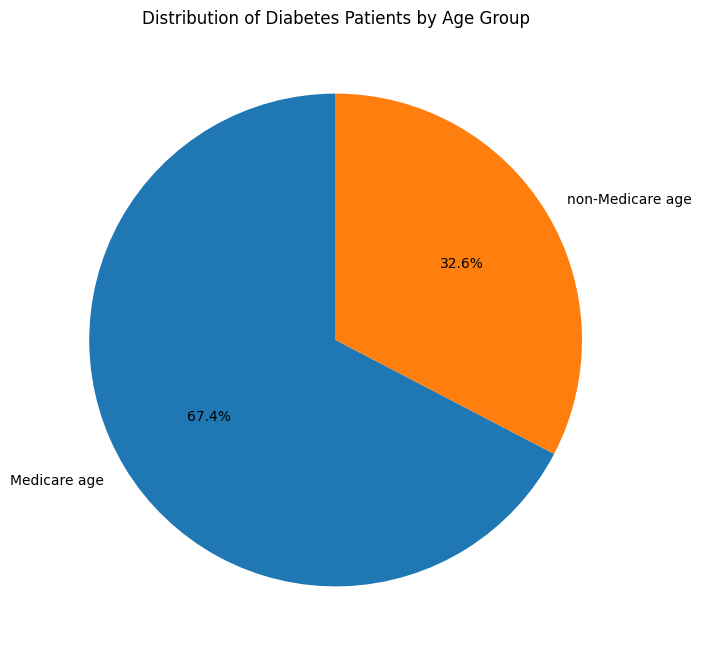

In [ ]:
import matplotlib.pyplot as plt

# Generate the pie chart directly from the 'count' column of desc_stats
plot = desc_stats['count'].plot.pie(autopct='%1.1f%%', startangle=90, figsize=(8, 8), title='Distribution of Diabetes Patients by Age Group')
plt.ylabel('') # Remove default 'count' label from the y-axis
plt.show()

# Conclusion
Encounters in this sample were broadly of Medicare age, defined as individuals who were 60 years old and above